# Profile likelihood for continuous-time LTI: CD-KF vs CD-EKF vs CD-UKF vs CD-EnKF vs CD-DPF

This **deep dive** builds a **profile likelihood** and **profile score** for a single parameter (one entry of the drift matrix $A$) in a continuous-time LTI system. All other parameters are **known** (no biases). Controls are simulated i.i.d. from $\mathcal{N}(0,1)$. We compare the profile log-likelihood computed with:

- **CD-KF** (exact continuous-discrete Kalman filter)
- **CD-EKF** (continuous-discrete extended Kalman filter)
- **CD-UKF** (continuous-discrete unscented Kalman filter)
- **CD-EnKF** (continuous-discrete ensemble Kalman filter)
- **CD-DPF** (continuous-discrete differentiable particle filter)

**Setup:** 2 states, 1 control, 1 output. We learn $\alpha = A_{0,0}$; $A_{1,1}$ and $L$, $B$, $H$, $R$ are fixed.

## Imports and config

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import Filter, LTI_continuous, SDESimulator
from dynestyx.inference.filters import (
    ContinuousTimeDPFConfig,
    ContinuousTimeEKFConfig,
    ContinuousTimeEnKFConfig,
    ContinuousTimeKFConfig,
    ContinuousTimeUKFConfig,
)

# Dimensions: 2 states, 1 control, 1 output
state_dim = 2
control_dim = 1
observation_dim = 1

## Continuous-time LTI model: one learned parameter $\alpha = A_{0,0}$, no biases

We set

$$
A = \begin{bmatrix} \alpha & 0 \\ 0 & -0.8 \end{bmatrix},
$$

with $L$, $B$, $H$, and $R$ fixed. Biases $b$, $d$ are zero.

For compatibility across all continuous-time filters (including CD-UKF), we set the direct observation-control term $D$ to `None` in this notebook.

In [2]:
def continuous_lti_one_param_model(
    obs_times=None,
    obs_values=None,
    predict_times=None,
    ctrl_times=None,
    ctrl_values=None,
):
    """Continuous-time LTI: only alpha = A[0,0] is sampled; all else fixed."""
    alpha = numpyro.sample("alpha", dist.Uniform(-1.2, 0.2))

    A = jnp.array([[alpha, 0.0], [0.0, -0.8]])
    L = 0.3 * jnp.eye(state_dim)
    H = jnp.array([[1.0, 0.0]])
    R = jnp.array([[0.5**2]])
    B = jnp.array([[0.1], [0.0]])
    D = None

    b = jnp.zeros(state_dim)
    d = jnp.zeros(observation_dim)

    initial_mean = jnp.zeros(state_dim)
    initial_cov = jnp.eye(state_dim)

    dynamics = LTI_continuous(
        A=A,
        L=L,
        H=H,
        R=R,
        B=B,
        b=b,
        D=D,
        d=d,
        initial_mean=initial_mean,
        initial_cov=initial_cov,
    )

    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

## True parameter, observation times, and controls $u_t \sim \mathcal{N}(0,1)$

Controls are provided on the same grid as observation times.

In [3]:
true_alpha = -0.4
obs_times = jnp.arange(0.0, 20.0, 0.1)
T = len(obs_times)

key = jr.PRNGKey(42)
key_ctrl, key_data = jr.split(key)

# Controls i.i.d. N(0,1)
ctrl_values = jr.normal(key_ctrl, shape=(T, control_dim))
ctrl_times = obs_times

print("True alpha:", true_alpha)
print("Observation times length:", T)
print("Controls shape:", ctrl_values.shape)

True alpha: -0.4
Observation times length: 200
Controls shape: (200, 1)


## Generate synthetic observations

Simulate the model with true $\alpha$ and the control trajectory to get $y_{1:T}$.

In [4]:
predictive = Predictive(
    continuous_lti_one_param_model,
    params={"alpha": jnp.array(true_alpha)},
    num_samples=1,
    exclude_deterministic=False,
)

with SDESimulator(dt0=1e-2):
    synthetic = predictive(
        key_data,
        predict_times=obs_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

obs_values = synthetic["f_observations"].squeeze(0).squeeze(0)
print("Observations shape:", obs_values.shape)

Observations shape: (200, 1)


## Profile log-likelihood

For each filter type (CD-KF, CD-EKF, CD-UKF, CD-EnKF, CD-DPF), we compute $\log p(y_{1:T} \mid \alpha)$ by running `Predictive` with `params={"alpha": alpha}`. The marginal log-likelihood is the `f_marginal_loglik` deterministic site. We `vmap` over the grid of $\alpha$ values.

**Note:** CD-EnKF and CD-DPF profiles are stochastic (one random key per run). Re-run those cells with a different key to see variability. CD-KF is deterministic for this linear-Gaussian model, and CD-EKF / CD-UKF are deterministic given fixed settings.

In [5]:
alpha_min, alpha_max = -1.0, 0.1
n_grid = 61
alpha_grid = jnp.linspace(alpha_min, alpha_max, n_grid)


def make_model(filter_type):
    """Build data-conditioned model with given continuous-time filter."""
    config = {
        "kf": ContinuousTimeKFConfig(warn=False),
        "ekf": ContinuousTimeEKFConfig(warn=False),
        "ukf": ContinuousTimeUKFConfig(warn=False),
        "enkf": ContinuousTimeEnKFConfig(
            n_particles=100,
            perturb_measurements=False,
            inflation_delta=0.00,
            warn=False,
        ),
        "dpf": ContinuousTimeDPFConfig(n_particles=500, warn=False),
    }[filter_type]

    def model():
        with Filter(filter_config=config):
            return continuous_lti_one_param_model(
                obs_times=obs_times,
                obs_values=obs_values,
                ctrl_times=ctrl_times,
                ctrl_values=ctrl_values,
            )

    return model


def get_marginal_loglik(alpha_val, key, filter_type):
    """Run Predictive with fixed alpha; return f_marginal_loglik site."""
    model = make_model(filter_type)
    pred = Predictive(
        model,
        params={"alpha": jnp.array(alpha_val)},
        num_samples=1,
        exclude_deterministic=False,
    )
    out = pred(key)
    return out["f_marginal_loglik"].squeeze()


def profile_log_likelihood(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile log p(y | alpha) via vmap over Predictive + f_marginal_loglik."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    profile = jax.vmap(
        lambda a, k: get_marginal_loglik(a, k, filter_type),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

## Plot profile log-likelihoods

All continuous-time filters should peak near the true $\alpha = -0.4$. CD-KF is exact for this linear-Gaussian continuous-discrete model; CD-EKF and CD-UKF are approximate filters generally, but should also be exact (with some additional comptation) in this linear case; CD-EnKF and CD-DPF are Monte Carlo approximations.

In [6]:
profile_kf, t_kf = profile_log_likelihood("kf", alpha_grid, jr.PRNGKey(10))
profile_ekf, t_ekf = profile_log_likelihood("ekf", alpha_grid, jr.PRNGKey(11))
profile_ukf, t_ukf = profile_log_likelihood("ukf", alpha_grid, jr.PRNGKey(12))
profile_enkf, t_enkf = profile_log_likelihood("enkf", alpha_grid, jr.PRNGKey(13))
profile_dpf, t_dpf = profile_log_likelihood("dpf", alpha_grid, jr.PRNGKey(14))

timings = {
    "CD-KF": t_kf,
    "CD-EKF": t_ekf,
    "CD-UKF": t_ukf,
    "CD-EnKF": t_enkf,
    "CD-DPF": t_dpf,
}
profiles = {
    "CD-KF": profile_kf,
    "CD-EKF": profile_ekf,
    "CD-UKF": profile_ukf,
    "CD-EnKF": profile_enkf,
    "CD-DPF": profile_dpf,
}

print("Filter     | max profile ll  | time (s)")
print("-----------|-----------------|--------")
for name in timings.keys():
    ll = float(jnp.nanmax(profiles[name]))
    print(f"{name:10} | {ll:15.4f} | {timings[name]:.3f}")

/Users/danwaxman/Documents/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:127: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)


Filter     | max profile ll  | time (s)
-----------|-----------------|--------
CD-KF      |       -163.0877 | 1.394
CD-EKF     |       -163.0877 | 0.563
CD-UKF     |       -163.0877 | 0.806
CD-EnKF    |       -162.9623 | 1.385
CD-DPF     |       -162.6935 | 29.891


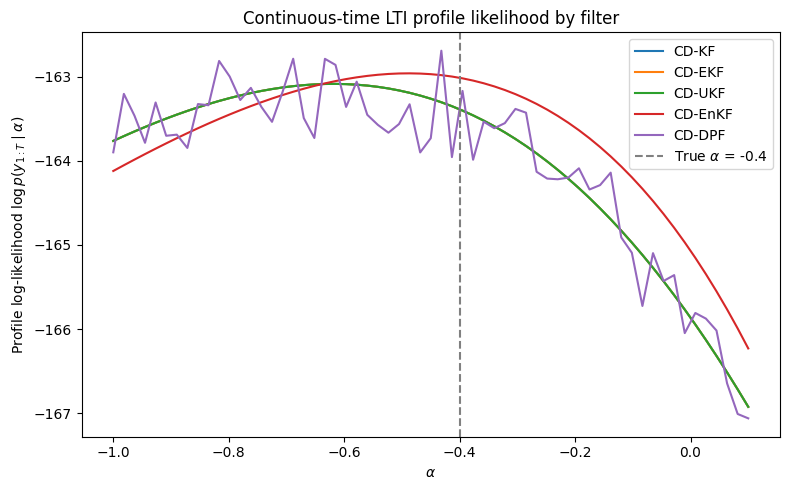

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(profile_kf), label="CD-KF", color="C0")
ax.plot(np.array(alpha_grid), np.array(profile_ekf), label="CD-EKF", color="C1")
ax.plot(np.array(alpha_grid), np.array(profile_ukf), label="CD-UKF", color="C2")
ax.plot(np.array(alpha_grid), np.array(profile_enkf), label="CD-EnKF", color="C3")
ax.plot(np.array(alpha_grid), np.array(profile_dpf), label="CD-DPF", color="C4")
ax.axvline(true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile log-likelihood $\\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title("Continuous-time LTI profile likelihood by filter")
plt.tight_layout()
plt.show()

The profile plot above gives a quick visual check of estimator agreement. In this run, deterministic filters (CD-KF, CD-EKF, CD-UKF) largely overlap, while CD-EnKF and CD-DPF can show small Monte Carlo variation. Intesting to note is that CD-EnKF profiles, for a fixed seed, are largely "smooth" but biased, whilst CD-PF profiles are unbiased but jumpy.

## Profile Score

For each filter type (CD-KF, CD-EKF, CD-UKF, CD-EnKF, CD-DPF), we can also compute $\nabla_\alpha \log p(y_{1:T} \mid \alpha)$ with direct auto-differentiation. The code to do this is simply wrapping `jax.grad` around the MLL profiles.

In [8]:
def profile_score(filter_type, alpha_vals, key=jr.PRNGKey(0)):
    """Profile score d/dalpha log p(y | alpha) via vmap + autodiff."""
    keys = jr.split(key, len(alpha_vals))
    t0 = time.perf_counter()
    get_score = jax.jit(
        lambda a, k: jax.grad(get_marginal_loglik)(a, k, filter_type)
    )
    profile = jax.vmap(
        lambda a, k: get_score(a, k),
        in_axes=(0, 0),
    )(alpha_vals, keys)
    elapsed = time.perf_counter() - t0
    return profile, elapsed

In [9]:
score_kf, ts_kf = profile_score("kf", alpha_grid, jr.PRNGKey(20))
score_ekf, ts_ekf = profile_score("ekf", alpha_grid, jr.PRNGKey(21))
score_ukf, ts_ukf = profile_score("ukf", alpha_grid, jr.PRNGKey(22))
score_enkf, ts_enkf = profile_score("enkf", alpha_grid, jr.PRNGKey(23))
score_dpf, ts_dpf = profile_score("dpf", alpha_grid, jr.PRNGKey(24))

score_timings = {
    "CD-KF": ts_kf,
    "CD-EKF": ts_ekf,
    "CD-UKF": ts_ukf,
    "CD-EnKF": ts_enkf,
    "CD-DPF": ts_dpf,
}
score_profiles = {
    "CD-KF": score_kf,
    "CD-EKF": score_ekf,
    "CD-UKF": score_ukf,
    "CD-EnKF": score_enkf,
    "CD-DPF": score_dpf,
}

print("Filter     | max score       | time (s)")
print("-----------|-----------------|--------")
for name in score_timings.keys():
    sc = float(jnp.nanmax(score_profiles[name]))
    print(f"{name:10} | {sc:15.4f} | {score_timings[name]:.3f}")

Filter     | max score       | time (s)
-----------|-----------------|--------
CD-KF      |          3.1576 | 3.295
CD-EKF     |          3.1576 | 2.751
CD-UKF     |          3.1576 | 3.477
CD-EnKF    |          3.7454 | 3.719
CD-DPF     |          4.3489 | 67.625


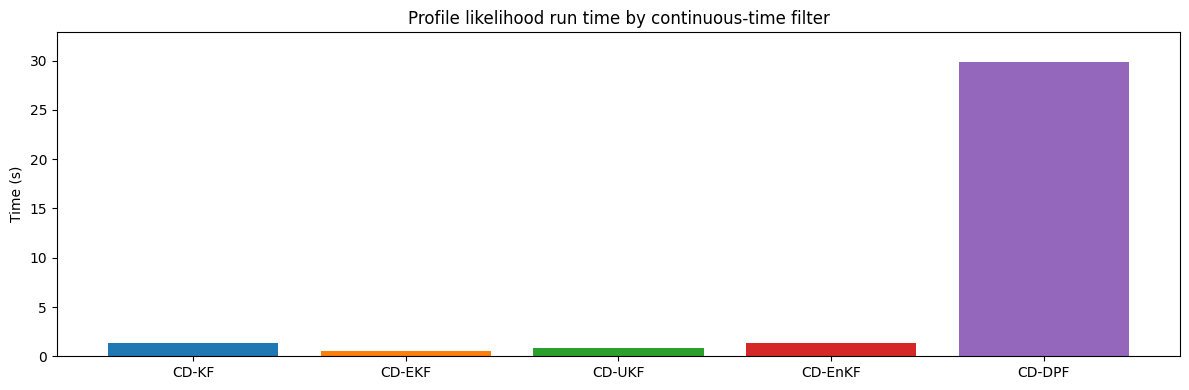

In [10]:
# Bar chart of profile likelihood run times
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
names = list(timings.keys())
times = [timings[n] for n in names]
ax.bar(names, times, color=["C0", "C1", "C2", "C3", "C4"])
ax.set_ylabel("Time (s)")
ax.set_ylim([0, 1.1 * max(times)])
ax.set_title("Profile likelihood run time by continuous-time filter")
plt.tight_layout()
plt.show()

The takeaways we see here are largely similar to the likeilhood example: PF is unbiased but jagged, whilst EnKF has a small bias but is smooth. Meanwhile, KF, EKF, and UKF are all exact for this problem.

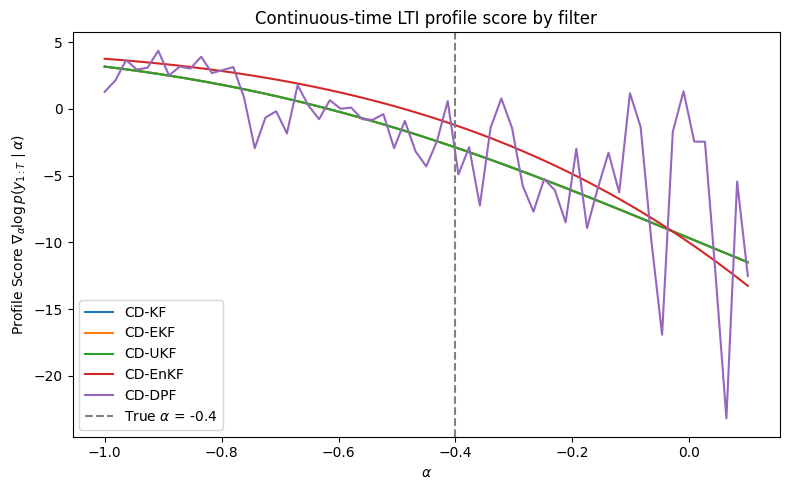

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(np.array(alpha_grid), np.array(score_kf), label="CD-KF", color="C0")
ax.plot(np.array(alpha_grid), np.array(score_ekf), label="CD-EKF", color="C1")
ax.plot(np.array(alpha_grid), np.array(score_ukf), label="CD-UKF", color="C2")
ax.plot(np.array(alpha_grid), np.array(score_enkf), label="CD-EnKF", color="C3")
ax.plot(np.array(alpha_grid), np.array(score_dpf), label="CD-DPF", color="C4")
ax.axvline(true_alpha, color="gray", linestyle="--", label=f"True $\\alpha$ = {true_alpha}")
ax.set_xlabel("$\\alpha$")
ax.set_ylabel("Profile Score $\\nabla_\\alpha \\log p(y_{1:T} \\mid \\alpha)$")
ax.legend()
ax.set_title("Continuous-time LTI profile score by filter")
plt.tight_layout()
plt.show()